<a href="https://colab.research.google.com/github/akshaykumar2972/Netflix-Data-Analysis/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the data from local file

In [2]:
df = pd.read_csv('/content/dataset.csv').drop_duplicates()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df['added_date'] = pd.to_datetime(df['date_added'], format='mixed').dt.date

In [6]:
# Randomly compare 20 values to verify
print(df[['date_added','added_date']].sample(20))

             date_added  added_date
8491     March 22, 2019  2019-03-22
3109  December 21, 2019  2019-12-21
8751    August 16, 2018  2018-08-16
1707  November 12, 2020  2020-11-12
699       June 17, 2021  2021-06-17
6872    January 1, 2019  2019-01-01
549        July 2, 2021  2021-07-02
7871  December 15, 2017  2017-12-15
1274  February 24, 2021  2021-02-24
4938      April 6, 2018  2018-04-06
372       July 30, 2021  2021-07-30
8095  September 8, 2017  2017-09-08
8004  December 31, 2019  2019-12-31
6247   November 1, 2018  2018-11-01
2734      April 1, 2020  2020-04-01
1818   October 19, 2020  2020-10-19
7355        May 7, 2017  2017-05-07
1375   January 27, 2021  2021-01-27
5375      July 14, 2017  2017-07-14
3875     April 30, 2019  2019-04-30


In [7]:
df['duration'].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [8]:
df['running_time'] = (pd.to_numeric(df['duration'].str.split(' ').str[0], errors='coerce').fillna(0).astype(int))

In [9]:
# Randomly compare 20 values to verify
print(df[['duration', 'running_time']].sample(20))

        duration  running_time
4813    1 Season             1
1145     111 min           111
7840    1 Season             1
8051     135 min           135
7847  13 Seasons            13
414       68 min            68
7524     158 min           158
942      138 min           138
8546     106 min           106
3542      82 min            82
4519      97 min            97
8060      94 min            94
1402   3 Seasons             3
4460      93 min            93
6851     161 min           161
6928      88 min            88
1989   3 Seasons             3
6689      94 min            94
3092    1 Season             1
907       85 min            85


In [10]:
df.drop(['date_added','duration', 'description'], axis=1, inplace=True)

In [11]:
df.describe()

,release_year,running_time
count,8807.000000,8807.000000
mean,2014.180198,69.823095
std,8.819312,50.822520
min,1925.000000,0.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


In [12]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,listed_in,added_date
count,8807,8807,8807,6173,7982,7976,8803,8807,8797
unique,8807,2,8807,4528,7692,748,17,514,1714
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,"Dramas, International Movies",2020-01-01
freq,1,6131,1,19,19,2818,3207,362,110


In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'release_year', 'rating', 'listed_in', 'added_date', 'running_time'],
      dtype='object')

In [14]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
release_year,0
rating,4
listed_in,0
added_date,10


In [15]:
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)

In [16]:
df.dropna(axis=0, inplace=True)

In [17]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
release_year,0
rating,0
listed_in,0
added_date,0


In [18]:
df.shape

(8793, 11)

In [19]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,Documentaries,2021-09-25,90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021-09-24,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021,TV-MA,"Docuseries, Reality TV",2021-09-24,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021-09-24,2


In [20]:
df[df['director'] != 'Unknown']['director'].value_counts().reset_index().head(10)

,director,count
0,Rajiv Chilaka,19
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Suhas Kadav,16
4,Jay Karas,14
5,Cathy Garcia-Molina,13
6,Martin Scorsese,12
7,Jay Chapman,12
8,Youssef Chahine,12
9,Steven Spielberg,11


**Most popular Movie stars**

In [21]:
cast_series = df[df['type'] == 'Movie']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_of_Movies'})

,Actor,Count_of_Movies
0,Anupam Kher,42
1,Shah Rukh Khan,35
2,Naseeruddin Shah,32
3,Akshay Kumar,30
4,Om Puri,30
5,Paresh Rawal,28
6,Amitabh Bachchan,28
7,Julie Tejwani,28
8,Rupa Bhimani,27
9,Boman Irani,27


**Most popular TV stars**

In [22]:
cast_series = df[df['type'] == 'TV Show']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_Of_TV_Shows'})

,Actor,Count_Of_TV_Shows
0,Takahiro Sakurai,25
1,Yuki Kaji,19
2,Junichi Suwabe,17
3,Daisuke Ono,17
4,Yuichi Nakamura,16
5,Ai Kayano,16
6,Jun Fukuyama,15
7,Yoshimasa Hosoya,15
8,David Attenborough,14
9,Kana Hanazawa,13


In [23]:
df[df['country'] != 'Unknown']['country'].value_counts().reset_index().head(10)

,country,count
0,United States,2812
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [24]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [25]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017,74 min,Movies,2017-04-04,0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2010,84 min,Movies,2016-09-16,0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2015,66 min,Movies,2016-08-15,0


In [26]:
df.drop(df[df['rating'].isin(['74 min', '84 min', '66 min'])].index, inplace=True)

In [27]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [28]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,Documentaries,2021-09-25,90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021-09-24,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021,TV-MA,"Docuseries, Reality TV",2021-09-24,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021-09-24,2


Text(0.5, 1.0, 'Distribution of TV Show Seasons')

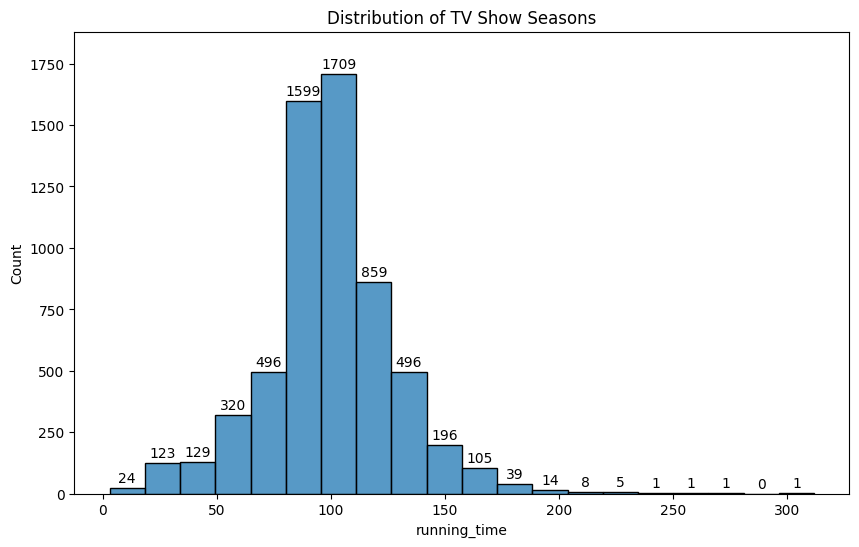

In [29]:
plt.figure(figsize=(10, 6))
ax_m = sns.histplot(x='running_time', data=df[df['type']=='Movie'], bins=20)
for container in ax_m.containers:
    ax_m.bar_label(container, padding=2)

plt.margins(y=0.1)

plt.title('Distribution of TV Show Seasons')

Text(0.5, 1.0, 'Distribution of TV Show Seasons')

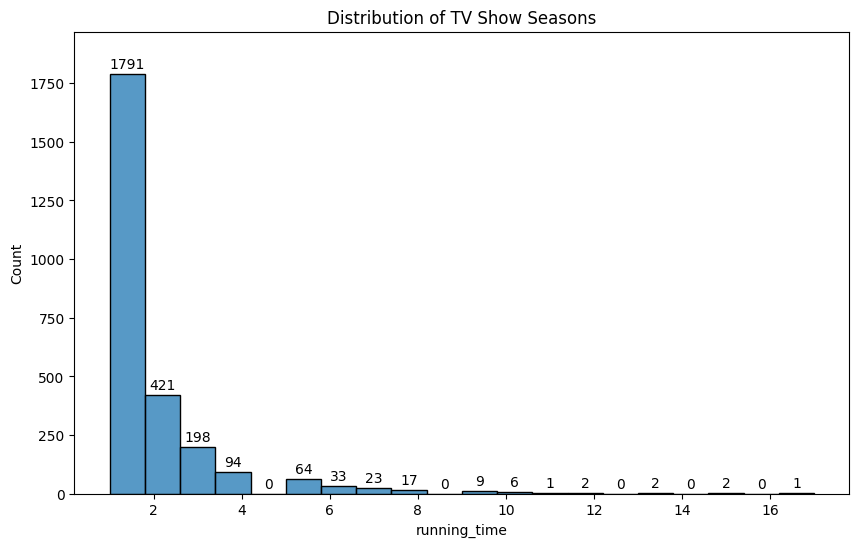

In [30]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(x='running_time', data=df[df['type']=='TV Show'], bins=20)
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.margins(y=0.1)

plt.title('Distribution of TV Show Seasons')

In [31]:
df[df['type']=='TV Show'][(df['running_time'] >= 5) & (df['running_time'] < 9)]

/tmp/ipykernel_326/3541923205.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['type']=='TV Show'][(df['running_time'] >= 5) & (df['running_time'] < 9)]


,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
21,s22,TV Show,Resurrection: Ertugrul,Unknown,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,2018,TV-14,"International TV Shows, TV Action & Adventure,...",2021-09-22,5
55,s56,TV Show,Nailed It,Unknown,"Nicole Byer, Jacques Torres",United States,2021,TV-PG,Reality TV,2021-09-15,6
65,s66,TV Show,Numberblocks,Unknown,"Beth Chalmers, David Holt, Marcel McCalla, Ter...",United Kingdom,2021,TV-Y,Kids' TV,2021-09-15,6
72,s73,TV Show,Jack Whitehall: Travels with My Father,Unknown,"Jack Whitehall, Michael Whitehall",United Kingdom,2021,TV-MA,"British TV Shows, Docuseries, International TV...",2021-09-14,5
82,s83,TV Show,Lucifer,Unknown,"Tom Ellis, Lauren German, Kevin Alejandro, D.B...",United States,2021,TV-14,"Crime TV Shows, TV Comedies, TV Dramas",2021-09-10,6
...,...,...,...,...,...,...,...,...,...,...,...
8378,s8379,TV Show,The L Word,Unknown,"Jennifer Beals, Leisha Hailey, Laurel Holloman...","Canada, United States",2009,TV-MA,"Romantic TV Shows, TV Dramas",2018-03-20,6
8422,s8423,TV Show,The Mind of a Chef,Unknown,"Anthony Bourdain, David Chang, Sean Brock, Apr...",United States,2016,TV-PG,Docuseries,2017-11-01,5
8557,s8558,TV Show,The West Wing,Unknown,"Martin Sheen, Rob Lowe, Allison Janney, John S...",United States,2005,TV-14,TV Dramas,2015-12-25,7
8710,s8711,TV Show,Weeds,Unknown,"Mary-Louise Parker, Hunter Parrish, Alexander ...",United States,2012,TV-MA,"TV Comedies, TV Dramas",2014-04-01,8


In [32]:
df[df['type']=='TV Show'][df['running_time'] >= 9]

/tmp/ipykernel_326/2981873950.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['type']=='TV Show'][df['running_time'] >= 9]


,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,"British TV Shows, Reality TV",2021-09-24,9
67,s68,TV Show,Saved by the Bell,Unknown,"Mark-Paul Gosselaar, Tiffani Thiessen, Mario L...",United States,1994,TV-PG,"Kids' TV, TV Comedies",2021-09-15,9
390,s391,TV Show,The Walking Dead,Unknown,"Andrew Lincoln, Steven Yeun, Norman Reedus, Ch...",United States,2019,TV-MA,"Classic & Cult TV, TV Action & Adventure, TV D...",2021-07-26,10
548,s549,TV Show,Grey's Anatomy,Unknown,"Ellen Pompeo, Sandra Oh, Katherine Heigl, Just...",United States,2020,TV-14,"Romantic TV Shows, TV Dramas",2021-07-03,17
1354,s1355,TV Show,Heartland,Unknown,"Amber Marshall, Michelle Morgan, Graham Wardle...",Canada,2019,TV-14,TV Dramas,2021-02-01,13
1480,s1481,TV Show,Still Game,Unknown,"Ford Kiernan, Paul Riley, Jane McCarry, Greg H...",United Kingdom,2018,TV-14,"British TV Shows, Classic & Cult TV, Internati...",2020-12-30,9
1622,s1623,TV Show,Stargate SG-1,Unknown,"Richard Dean Anderson, Michael Shanks, Amanda ...","United States, Canada",2006,TV-MA,"Classic & Cult TV, TV Action & Adventure, TV S...",2020-12-01,10
1701,s1702,TV Show,American Horror Story,Unknown,"Evan Peters, Sarah Paulson, Jessica Lange, Den...",United States,2019,TV-MA,"TV Horror, TV Mysteries, TV Thrillers",2020-11-13,9
1759,s1760,TV Show,LEGO Ninjago: Masters of Spinjitzu,Unknown,"Vincent Tong, Jillian Michaels, Ian James Corl...","Denmark, Singapore, Canada, United States",2019,TV-Y7,Kids' TV,2020-11-01,10
1998,s1999,TV Show,Call the Midwife,Philippa Lowthorpe,"Vanessa Redgrave, Bryony Hannah, Helen George,...",United Kingdom,2020,TV-MA,"British TV Shows, International TV Shows, TV D...",2020-09-15,9


In [33]:
df['added_date'] = pd.to_datetime(df['added_date'])
df['year_month'] = df['added_date'].dt.to_period('M')

In [34]:
all_counts = df.groupby(['year_month','type'])['show_id'].count().reset_index(name='count')
all_counts['year_month'] = all_counts['year_month'].dt.to_timestamp()

Text(0.5, 1.0, 'Total Movies and TV Shows Added Over Time')

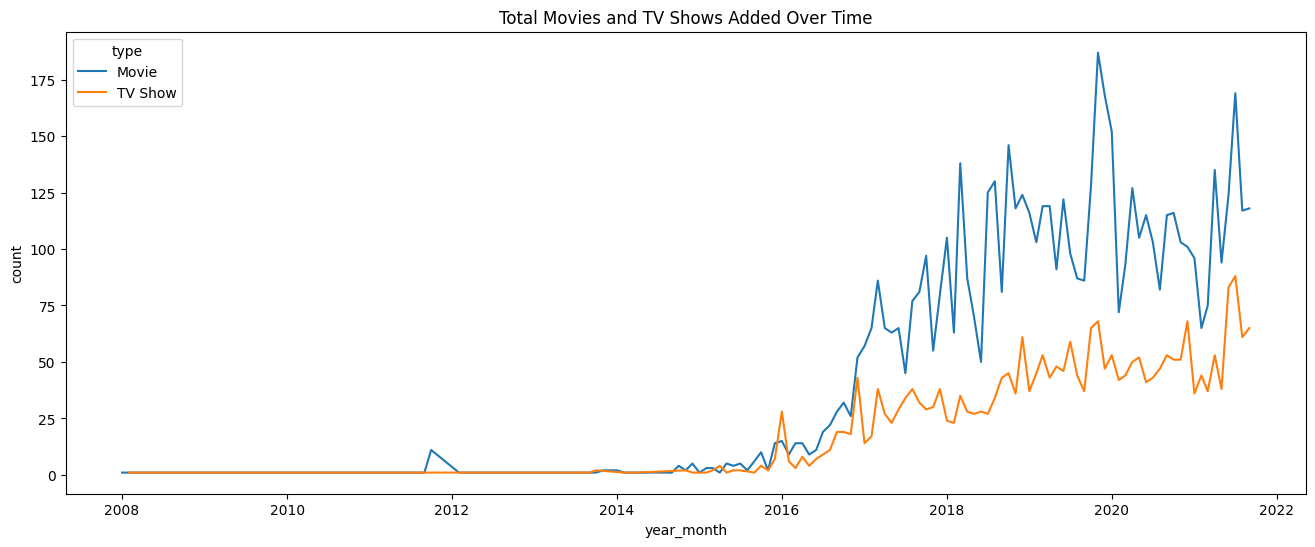

In [35]:
plt.figure(figsize=(16, 6))
sns.lineplot(x='year_month', y='count', data=all_counts, hue='type')
plt.title('Total Movies and TV Shows Added Over Time')

In [36]:
counts = df.groupby(['year_month', 'type']).size().reset_index(name='count')
counts = counts.sort_values('year_month')
counts['cumulative_count'] = counts.groupby('type')['count'].cumsum()
counts['year_month'] = counts['year_month'].dt.to_timestamp()

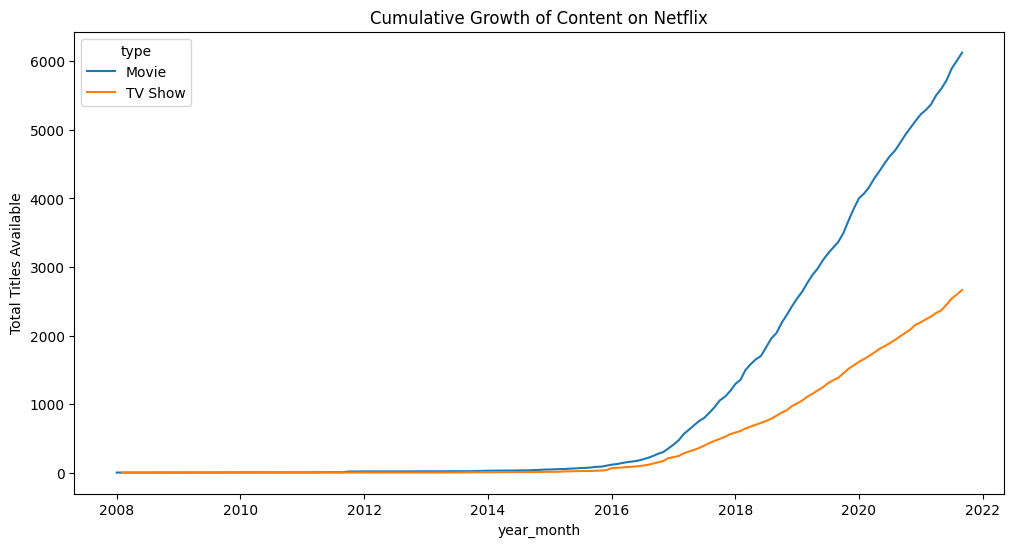

In [37]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=counts, x='year_month', y='cumulative_count', hue='type')
plt.title('Cumulative Growth of Content on Netflix')
plt.ylabel('Total Titles Available')
plt.show()

In [38]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time,year_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,Documentaries,2021-09-25,90,2021-09
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2021-09-24,2,2021-09
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,1,2021-09
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021,TV-MA,"Docuseries, Reality TV",2021-09-24,1,2021-09
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2021-09-24,2,2021-09


In [39]:
df.groupby(['country','type'])['show_id'].count().reset_index(name='count').sort_values('country')

,country,type,count
0,", France, Algeria",Movie,1
1,", South Korea",TV Show,1
2,Argentina,Movie,38
3,Argentina,TV Show,18
4,"Argentina, Brazil, France, Poland, Germany, De...",Movie,1
...,...,...,...
844,Venezuela,Movie,1
845,"Venezuela, Colombia",Movie,1
846,Vietnam,Movie,7
847,West Germany,Movie,1


In [40]:
country_series = df['country'].str.split(',').explode().str.strip()
country_series = country_series[~country_series.isin(['Unknown', ''])]
country_series.value_counts()

,count
country,
United States,3681
India,1046
United Kingdom,805
Canada,445
France,393
...,...
Sudan,1
Panama,1
Uganda,1


In [41]:
# Creating a temporary exploded dataframe
df_exploded = df.assign(country=df['country'].str.split(',')).explode('country')

In [42]:
# Cleaning up leading/trailing spaces and remove empty values
df_exploded['country'] = df_exploded['country'].str.strip()
df_exploded = df_exploded[~df_exploded['country'].isin(['', 'Unknown'])]

In [43]:
# Performing the groupby aggregation
final_output = (df_exploded.groupby(['country', 'type'])['show_id'].count().reset_index(name='count'))

In [44]:
wide_df = final_output.pivot(index='country', columns='type', values='count').fillna(0).reset_index()
wide_df = wide_df.rename(columns={'Movie': 'Movies', 'TV Show': 'TVShows'})
wide_df = wide_df.astype({'Movies':int,'TVShows':int})

In [45]:
#fetching top 20 countries with most number of Movies/Shows produced
df_exploded.groupby(['country'])['show_id'].count().reset_index(name='count').sort_values('count', ascending=False).head(20)['country']

,country
115,United States
45,India
114,United Kingdom
20,Canada
36,France
53,Japan
102,Spain
100,South Korea
38,Germany
67,Mexico


In [49]:
wide_df = wide_df[wide_df['country'].isin(df_exploded.groupby(['country'])['show_id'].count().reset_index(name='count').sort_values('count', ascending=False).head(20)['country'])]

In [51]:
wide_df

type,country,Movies,TVShows
4,Argentina,71,20
6,Australia,94,64
15,Brazil,66,31
20,Canada,319,126
23,China,114,48
33,Egypt,102,15
36,France,303,90
38,Germany,182,44
42,Hong Kong,100,5
45,India,962,84


In [52]:
total_content = wide_df['Movies'] + wide_df['TVShows']
wide_df['Movies'] = (wide_df['Movies'] / total_content * 100).round(2)
wide_df['TVShows'] = (wide_df['TVShows'] / total_content * 100).round(2)

In [53]:
wide_df.index.name = None
wide_df = wide_df.reset_index(drop=True)

In [54]:
print(wide_df)

type         country  Movies  TVShows
0          Argentina   78.02    21.98
1          Australia   59.49    40.51
2             Brazil   68.04    31.96
3             Canada   71.69    28.31
4              China   70.37    29.63
5              Egypt   87.18    12.82
6             France   77.10    22.90
7            Germany   80.53    19.47
8          Hong Kong   95.24     4.76
9              India   91.97     8.03
10         Indonesia   95.56     4.44
11             Italy   74.75    25.25
12             Japan   37.66    62.34
13            Mexico   65.68    34.32
14           Nigeria   91.26     8.74
15       South Korea   26.41    73.59
16             Spain   73.71    26.29
17            Turkey   73.45    26.55
18    United Kingdom   66.34    33.66
19     United States   74.68    25.32


In [55]:
wide_df['Movies'] = wide_df['Movies'].apply(lambda x: f"{x:.2f}%")
wide_df['TVShows'] = wide_df['TVShows'].apply(lambda x: f"{x:.2f}%")

In [56]:
wide_df

type,country,Movies,TVShows
0,Argentina,78.02%,21.98%
1,Australia,59.49%,40.51%
2,Brazil,68.04%,31.96%
3,Canada,71.69%,28.31%
4,China,70.37%,29.63%
5,Egypt,87.18%,12.82%
6,France,77.10%,22.90%
7,Germany,80.53%,19.47%
8,Hong Kong,95.24%,4.76%
9,India,91.97%,8.03%


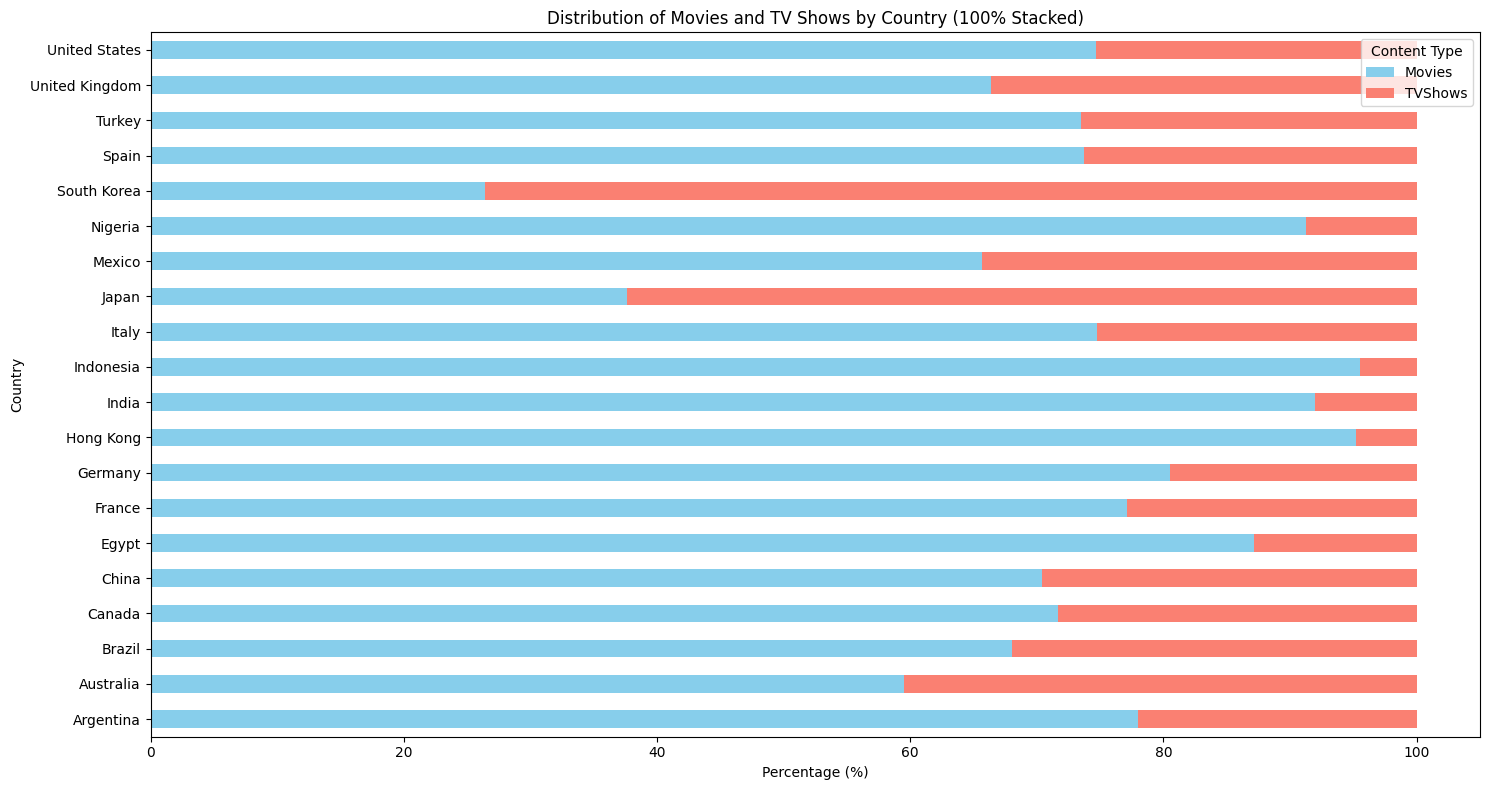

In [59]:
# Create a copy to avoid modifying the original wide_df if needed later
plot_df = wide_df.copy()

# Convert 'Movies' and 'TVShows' columns from percentage strings back to numeric
plot_df['Movies'] = plot_df['Movies'].str.replace('%', '').astype(float)
plot_df['TVShows'] = plot_df['TVShows'].str.replace('%', '').astype(float)

# Set country as index for plotting stacked bars
plot_df_indexed = plot_df.set_index('country')

# Create the 100% stacked horizontal bar chart
plot_df_indexed[['Movies', 'TVShows']].plot(kind='barh', stacked=True, figsize=(15, 8), color=['skyblue', 'salmon'])

plt.title('Distribution of Movies and TV Shows by Country (100% Stacked)')
plt.xlabel('Percentage (%)') # Swapped x and y labels
plt.ylabel('Country') # Swapped x and y labels
plt.xticks(rotation=0) # No rotation needed for x-axis labels
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()